In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

## Task 1 — Convolution Mechanics: Filters and Shapes

### Part A — Handcrafted filters.

In [22]:
transform=transforms.ToTensor()
dataset=datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
image_tensor, label=dataset[0]
print(image_tensor.shape)
image_tensor_batched=image_tensor.unsqueeze(0)
print(image_tensor_batched.shape)

torch.Size([3, 32, 32])
torch.Size([1, 3, 32, 32])


In [23]:
vertical=torch.tensor([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
horizontal=vertical.t()
blur=torch.ones((3, 3)) / 9.0

def conv_layer(kernel):
    conv=nn.Conv2d(3, 1, kernel_size=3, padding=1)
    weight=kernel.expand(1,3,3,3)
    with torch.no_grad():
        conv.weight.copy_(weight)
        conv.bias.zero_()
    return conv

vertical_edge_detector=conv_layer(vertical)
horizontal_edge_detector=conv_layer(horizontal)
blur_filter=conv_layer(blur)

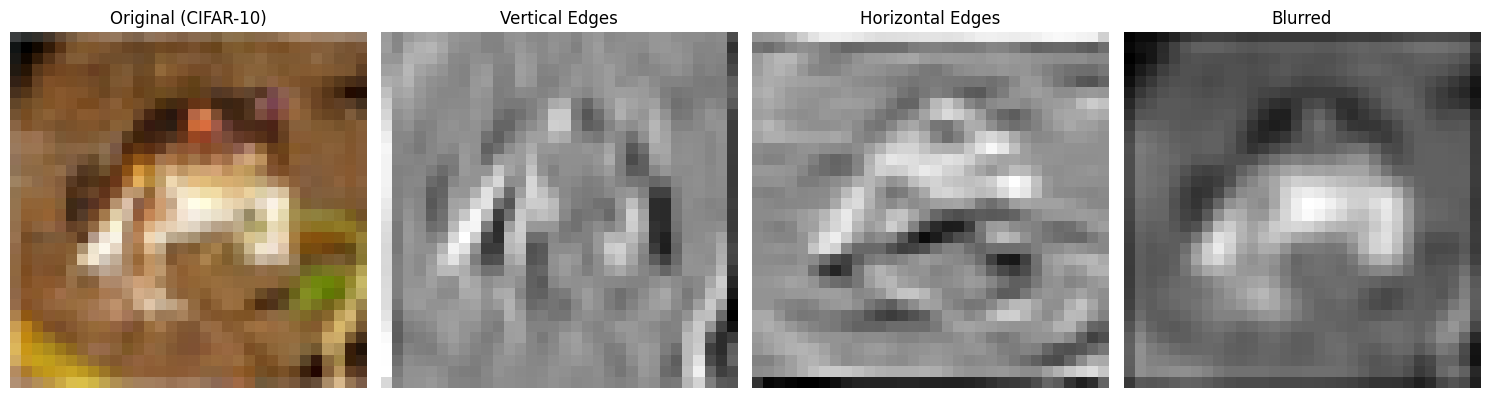

In [24]:
with torch.no_grad():
    v_out = vertical_edge_detector(image_tensor_batched)
    h_out = horizontal_edge_detector(image_tensor_batched)
    b_out = blur_filter(image_tensor_batched)

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

orig_img = image_tensor_batched.squeeze(0).permute(1, 2, 0)
axes[0].imshow(orig_img)
axes[0].set_title("Original (CIFAR-10)")
axes[0].axis("off")

axes[1].imshow(v_out.squeeze().numpy(), cmap="gray")
axes[1].set_title("Vertical Edges")
axes[1].axis("off")

axes[2].imshow(h_out.squeeze().numpy(), cmap="gray")
axes[2].set_title("Horizontal Edges")
axes[2].axis("off")

axes[3].imshow(b_out.squeeze().numpy(), cmap="gray")
axes[3].set_title("Blurred")
axes[3].axis("off")

plt.tight_layout()
plt.show()

The Vertical and Horizontal Edge Detectors highlight structural boundaries by identifying sharp intensity changes in their respective directions, making outlines and contours more prominent. In contrast, the Blur Filter averages neighboring pixel values to smooth the image, effectively reducing noise while softening sharp details.

### Part B — Shape tracking.

In [25]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
    def forward(self,x):
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)
        x = torch.relu(self.conv2(x))
        x = self.pool2(x)
        return x
    
model = TinyCNN()
output=model(image_tensor_batched)
print(f"Input shape: {image_tensor_batched.shape}")
print(f"Output shape: {output.shape}")

x = torch.randn(8, 3, 32, 32)

layers = {
    "conv1": model.conv1,
    "pool1": model.pool1,
    "conv2": model.conv2,
    "pool2": model.pool2
}

table_data = []
current_input = x
for name, layer in layers.items():
    input_shape = tuple(current_input.shape) 
    current_input = layer(current_input)      
    output_shape = tuple(current_input.shape) 
    
    table_data.append({
        "Layer": name,
        "Input Shape": str(input_shape),
        "Output Shape": str(output_shape)
    })

df = pd.DataFrame(table_data)

print(df.to_string(index=False))

Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 32, 8, 8])
Layer     Input Shape    Output Shape
conv1  (8, 3, 32, 32) (8, 16, 32, 32)
pool1 (8, 16, 32, 32) (8, 16, 16, 16)
conv2 (8, 16, 16, 16) (8, 32, 16, 16)
pool2 (8, 32, 16, 16)   (8, 32, 8, 8)


## Task 2 — Train a Small CNN on CIFAR-10

In [26]:
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super(CIFAR10CNN, self).__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

model = CIFAR10CNN()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"The parameter cout of the model: {total_params:,}")

The parameter cout of the model: 1,117,354


Epoch 1/15 | Train Acc: 89.93% | Val Acc: 80.50%
Epoch 2/15 | Train Acc: 90.61% | Val Acc: 79.10%
Epoch 3/15 | Train Acc: 91.27% | Val Acc: 79.91%
Epoch 4/15 | Train Acc: 91.72% | Val Acc: 80.12%
Epoch 5/15 | Train Acc: 92.43% | Val Acc: 79.28%
Epoch 6/15 | Train Acc: 92.87% | Val Acc: 80.42%
Epoch 7/15 | Train Acc: 93.26% | Val Acc: 79.17%
Epoch 8/15 | Train Acc: 93.75% | Val Acc: 80.67%
Epoch 9/15 | Train Acc: 93.62% | Val Acc: 79.79%
Epoch 10/15 | Train Acc: 94.45% | Val Acc: 80.34%
Epoch 11/15 | Train Acc: 94.46% | Val Acc: 80.55%
Epoch 12/15 | Train Acc: 94.70% | Val Acc: 80.10%
Epoch 13/15 | Train Acc: 94.82% | Val Acc: 79.26%
Epoch 14/15 | Train Acc: 95.17% | Val Acc: 80.02%
Epoch 15/15 | Train Acc: 95.17% | Val Acc: 80.60%


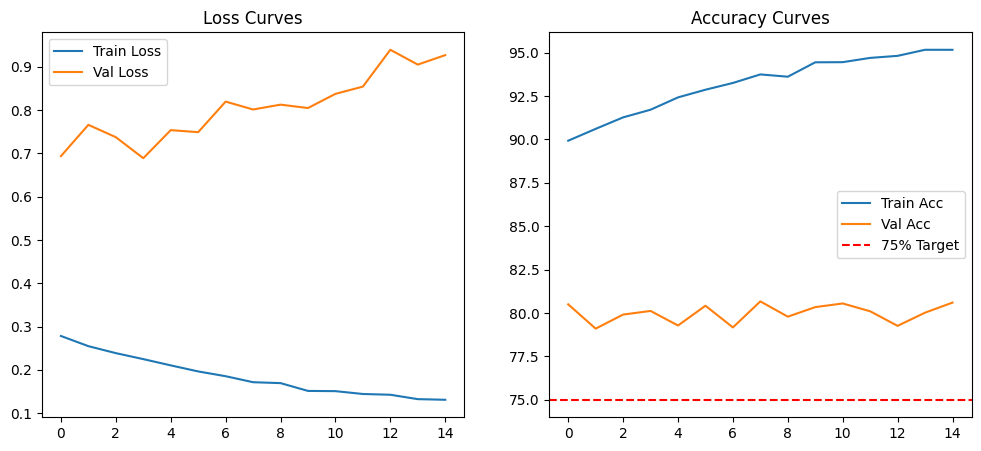

In [30]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)

test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs = 15

for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100. * correct / total)

    # --- VALIDATION ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_losses.append(val_loss / len(test_loader))
    val_accs.append(100. * val_correct / val_total)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_accs[-1]:.2f}% | Val Acc: {val_accs[-1]:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.axhline(y=75, color='r', linestyle='--', label='75% Target')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

## Task 3 — Data Augmentation

Epoch 1/15 | Train Acc: 38.44% | Val Acc: 49.67%
Epoch 2/15 | Train Acc: 54.96% | Val Acc: 63.03%
Epoch 3/15 | Train Acc: 60.80% | Val Acc: 67.80%
Epoch 4/15 | Train Acc: 64.25% | Val Acc: 67.79%
Epoch 5/15 | Train Acc: 66.72% | Val Acc: 70.15%
Epoch 6/15 | Train Acc: 68.48% | Val Acc: 74.25%
Epoch 7/15 | Train Acc: 69.91% | Val Acc: 74.51%
Epoch 8/15 | Train Acc: 71.18% | Val Acc: 74.78%
Epoch 9/15 | Train Acc: 72.16% | Val Acc: 76.18%
Epoch 10/15 | Train Acc: 72.70% | Val Acc: 74.86%
Epoch 11/15 | Train Acc: 73.71% | Val Acc: 75.95%
Epoch 12/15 | Train Acc: 74.56% | Val Acc: 78.87%
Epoch 13/15 | Train Acc: 75.26% | Val Acc: 74.54%
Epoch 14/15 | Train Acc: 75.57% | Val Acc: 71.29%
Epoch 15/15 | Train Acc: 76.22% | Val Acc: 79.10%


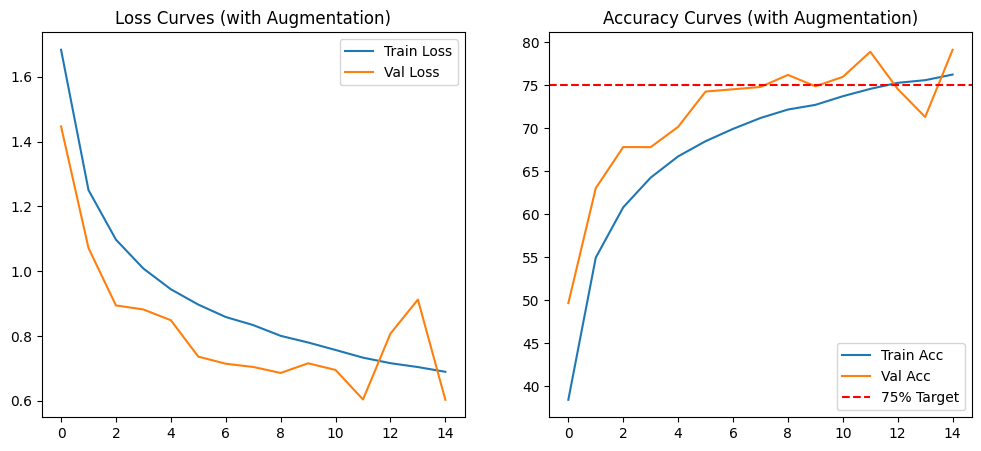

In [32]:
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_tf)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)

test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CIFAR10CNN().to(device) 

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs = 15

for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100. * correct / total)

    # --- VALIDATION ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_losses.append(val_loss / len(test_loader))
    val_accs.append(100. * val_correct / val_total)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_accs[-1]:.2f}% | Val Acc: {val_accs[-1]:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curves (with Augmentation)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.axhline(y=75, color='r', linestyle='--', label='75% Target')
plt.title('Accuracy Curves (with Augmentation)')
plt.legend()
plt.show()

| Run                          | Best Val Accuracy | Train/Val Gap      |
|-----------------------------|-------------------|--------------------|
| **Task 2 (No Augmentation)**   | 80.60%            | ~14.5% (High)      |
| **Task 3 (With Augmentation)** | 79.10%            | ~ -2.8% (Negative) |

The implementation of data augmentation significantly transformed the model's learning behavior by preventing it from merely memorizing pixel patterns, effectively resolving the severe overfitting issue observed in the first experiment—where training accuracy reached 95% while validation loss spiked. In the second experiment, although the training accuracy decreased to 76.22%, the validation accuracy remained strong at 79.10% and the validation loss stayed aligned with the training loss. This shift demonstrates that while the "richer" transform pipeline made the training task more challenging, it forced the model to learn more robust, generalized features, resulting in a much more reliable and stable performance on unseen data.